In the bias analysis, we predicted values from seen expression data of the same cell type across stimulation condition. Here, we show that, when predicting values on ALL in-distribution expression data (all seen data --> test condition), the global bias term is well-mixed independent of adverserial training. This tells us that the adverserial approach is not removing stimulation information from the input gene expression vector. 

Conceptually see this [slide](https://docs.google.com/presentation/d/1V0Ct_31illsrtmAhYfzzG0ehO-tz_pGw4gLrcWHfI6Q/edit?usp=sharing):

![Alt Text](./Global_Bias.png)

Notebook 06Di represents Scenario 1, whereas this notebook represents Scenario 2.

In [119]:
import os

import pandas as pd
import scanpy as sc
import numpy as np

import torch

from sklearn.metrics import normalized_mutual_info_score

import matplotlib.pyplot as plt
import seaborn as sns

In [120]:
import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS.preprocess import embed_tf_activity

In [121]:
seed = 888
device = "cuda" if torch.cuda.is_available() else "cpu"

data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'

In [122]:
n_cores = 20
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

Load the model and associated data:

In [123]:
trainer = io.read_pickled_object(os.path.join(data_path, 'processed', 'Kang_fullbest_trainer.pickle'))
mod = trainer.mod

trainer_na = io.read_pickled_object(os.path.join(data_path, 'processed', 'Kang_no_adverserial_trainer.pickle'))
mod_na = trainer_na.mod


test_cells = open(os.path.join(data_path, 'processed', 'data_split_barcodes', 'kang_test.txt')).read().splitlines()


In [124]:
tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
tf_adata.obs['condition'] = tf_adata.obs['stim'].astype(str) + '^' + tf_adata.obs['seurat_annotations'].astype(str)

adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_sn_ppis.csv'), index_col = 0)

In [125]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

Next, let's see what the global bias looks like in UMAP space. To do this, we run the following prediction: for each condition (stimulation + cell type), we predict what that cell type would look like in the opposite stimulation condition from ALL the in-distribution data (from all other conditions). 

In [15]:
train_cells = trainer.X_train.index.tolist()
stim_map = {'STIM': 1, 'CTRL': 0}

cov_idx_map = dict(zip(mod.signaling_network.covariates['seurat_annotations'], 
                       mod.signaling_network.covariates_idx['seurat_annotations']))
cov_rev_map = {v:k for k,v in cov_idx_map.items()}

In [127]:
only_within_celltype = False # only change stim within a cell type
full_expr, full_X, full_covariates = None, None, None

for cond in tf_adata.obs.loc[test_cells, :].condition.unique():
    stim, ct = cond.split('^')

    if only_within_celltype:
        train_cells_cond = tf_adata.obs[(tf_adata.obs.index.isin(train_cells)) & 
                                        (tf_adata.obs['condition'] == rev_stim[stim] + '^' + ct)].index.tolist()
    else:
        train_cells_cond = train_cells
    
    expr_test = mod.df_to_tensor(mod.expr.loc[train_cells_cond, :])

    X_test_df = pd.DataFrame(data = {'IFNB1': [stim_map[stim]]*len(train_cells_cond)})
    X_test = mod.df_to_tensor(X_test_df)

    covariates_idx_test = torch.tensor([cov_idx_map[ct]]*len(train_cells_cond), 
                                       device = mod.device, dtype = torch.int64).view(-1,1)
    
    if full_expr is None:
        full_expr = expr_test
    else: 
        full_expr = torch.cat((full_expr, expr_test), dim = 0)
        
    if full_X is None:
        full_X = X_test
    else: 
        full_X = torch.cat((full_X, X_test), dim = 0)

    if full_covariates is None:
        full_covariates = covariates_idx_test
    else: 
        full_covariates = torch.cat((full_covariates, covariates_idx_test), dim = 0)    

In [128]:
mod_na.eval()
with torch.inference_mode():
    y_predicted, Y_full, biases = mod_na(X_in = full_X, covariates_idx = full_covariates, expr = full_expr)
    bias_global_na, bias_mu, bias_log_sigma_squared = biases 

mod.eval()
with torch.inference_mode():
    y_predicted, Y_full, biases = mod(X_in = full_X, covariates_idx = full_covariates, expr = full_expr)
    bias_global, bias_mu, bias_log_sigma_squared = biases

Clustering and dimensionality reduction:

In [27]:
obs = pd.DataFrame(full_covariates.detach().cpu().numpy())
obs.columns = ['seurat_annotations']
obs.seurat_annotations = obs.seurat_annotations.map(cov_rev_map)

# perfect
onehot_df = pd.get_dummies(obs.seurat_annotations).astype(int)
one_hot = sc.AnnData(X = onehot_df, obs = obs)
embed_tf_activity(one_hot, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1, 
                 n_components = one_hot.shape[1] - 1)
# perfectly random
np.random.seed(seed)
rand_idx = np.random.permutation(onehot_df.index)
rand_obs = obs.copy()
rand_obs.index = rand_idx
rand = sc.AnnData(X = onehot_df.loc[rand_idx, :], obs = rand_obs)
embed_tf_activity(rand, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1, 
                 n_components = rand.shape[1] - 1)

# no adverserial
bias_adata_na = sc.AnnData(X = bias_global_na.detach().cpu().numpy(), obs = obs)
embed_tf_activity(bias_adata_na, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1)

# full model
bias_adata = sc.AnnData(X = bias_global.detach().cpu().numpy(), obs = obs)
embed_tf_activity(bias_adata, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1)


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/home/hmbaghda/Projects/scLEMBAS/scLEMBAS/preprocess.py:290: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achi

In [28]:
def adata_dimviz(adata, reduction_type, cat, subset_idx = None):
    viz_df = pd.DataFrame(adata.obsm['X_' + reduction_type])
    viz_df = pd.concat([viz_df, pd.DataFrame(adata.obs[cat]).reset_index(drop = True)], ignore_index = True, axis = 1)

    viz_df.columns = [reduction_type.upper() + str(i+1) for i in range(viz_df.shape[1])]
    viz_df.columns = viz_df.columns[:-1].tolist() + [cat]
    
    if subset_idx is not None:
        viz_df = viz_df.loc[subset_idx, :]
    
    return viz_df


We'll visualize a random subset of 5000 cells because the dataset is large.

In [29]:
adata_types = ['Perfect Information', 'Completely Random', 
                     'Model No Adverserial', 'Model with Adverserial']
adata_dict = dict(zip(adata_types, 
                     [one_hot, rand, bias_adata_na, bias_adata]))

The top left panel is clustering/dimreduction results on one-hot encodings of the predicted cell types. The top right panel is this same information, but with the barcodes permuted. These reppresent baseline NMI values from the clustering pipeline. 

''

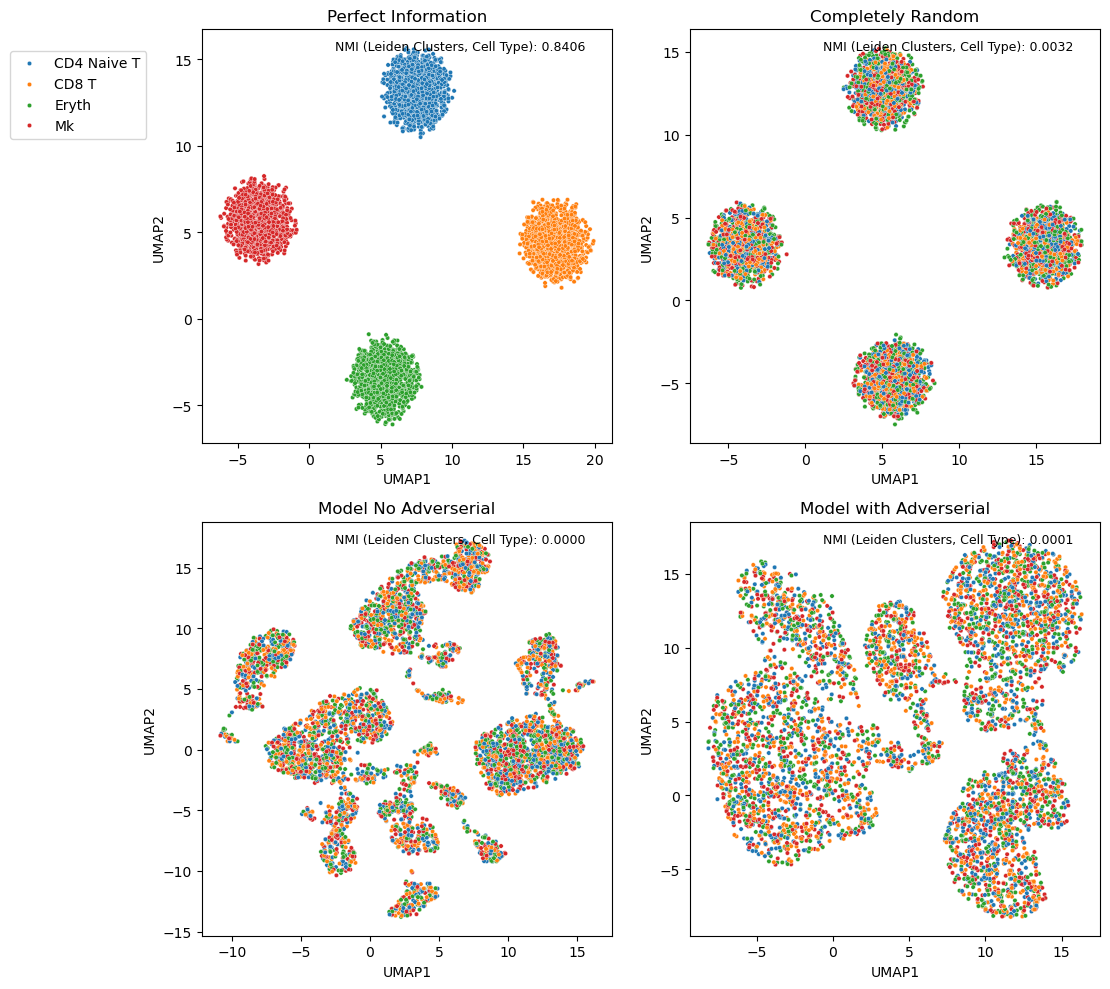

In [30]:
fig, ax = plt.subplots(ncols = 2, nrows = 2, figsize = (10,10))
ax = ax.flatten()

subset_size = 5000
subset_cells = np.random.choice(list(range(y_predicted.shape[0])), size=subset_size, replace=False)

for i, (adata_type, adata) in enumerate(adata_dict.items()):
    viz_df = adata_dimviz(adata = adata, reduction_type = 'umap', cat = 'seurat_annotations', 
                         subset_idx = subset_cells)
    nmi = normalized_mutual_info_score(adata.obs.leiden, adata.obs.seurat_annotations)

    sns.scatterplot(data = viz_df, x = 'UMAP1', y = 'UMAP2', hue = 'seurat_annotations', 
                    s=10,
                    ax = ax[i])
    ax[i].annotate('NMI (Leiden Clusters, Cell Type): {:.4f}'.format(nmi),
                    xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
    ax[i].set_title(adata_type)

lines, labels = ax[3].get_legend_handles_labels()
fig.legend(lines, labels, loc="upper left", bbox_to_anchor=(-0.125, 0.95))
for ax_ in ax:
    ax_.legend().remove()
    
    
fig.tight_layout()
;

<span style="color:red">TODO:</span> color by stimulation condition if change the train-test split
